In [1]:
import jax
import jax.random as jrandom
import jax.numpy as jnp
from jax import config
# config.update("jax_enable_x64", True)

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, \
    VirtualBrownianTree, STLAControlTerm, STLAMultiTerm, SEA, ShARK, PIDController, LevyVal, ALIGN
from test import get_errs

import diffrax
import math
import matplotlib.pyplot as plt

def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[:2], y[2:]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=y.dtype).flatten()
    return d_y


def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2 * gamma * u) * jnp.ones((2,), dtype=y.dtype)
    d_y = jnp.concatenate((jnp.zeros((2, 2), dtype=y.dtype), jnp.diag(d_v)), axis=0)
    return d_y

args = (jnp.float32(0.3), jnp.float32(5.0), lambda x: x)
y0 = jnp.array([0, 0, 0, 0], dtype=jnp.float32)
t0, t1 = 0.3, 15
harmonic_osc = (drift, diffusion, args, y0, t0, t1)

num_samples = 1000
keys = jrandom.split(jrandom.PRNGKey(2), num=num_samples)
print(jax.devices())

[cuda(id=0)]


In [2]:
hs, errs = get_errs(keys, harmonic_osc, ALIGN(), ALIGN(), 0.005)

[0.025 0.05  0.1   0.2   0.4   0.8  ]
[4.1697309e-03 1.7106868e-02 6.9093332e-02 2.8223184e-01 1.1702268e+00
 4.7142987e+00]


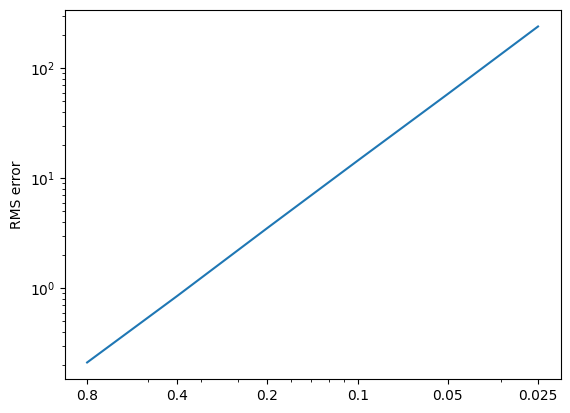

In [3]:
plt.plot(1/hs, 1/errs)
plt.yscale("log")
plt.xscale("log")
plt.xticks(ticks=1/hs, labels=hs)
plt.ylabel("RMS error")
plt.show()

In [4]:
errs[1:]/errs[:-1]

Array([4.102631 , 4.0389237, 4.084791 , 4.146332 , 4.0285344], dtype=float32)